# Caso Práctico: Limpieza de Datos de Retail (Tienda Tecnológica)
En este notebook realizaremos la limpieza de un dataset de ventas con errores comunes:
1. **Valores Negativos:** Errores de digitación en ingresos.
2. **Nulos (NaN):** Datos faltantes en productos clave.
3. **Duplicados:** Registros repetidos que inflan las ventas.
4. **Fechas Incoherentes:** Formatos de fecha mixtos.

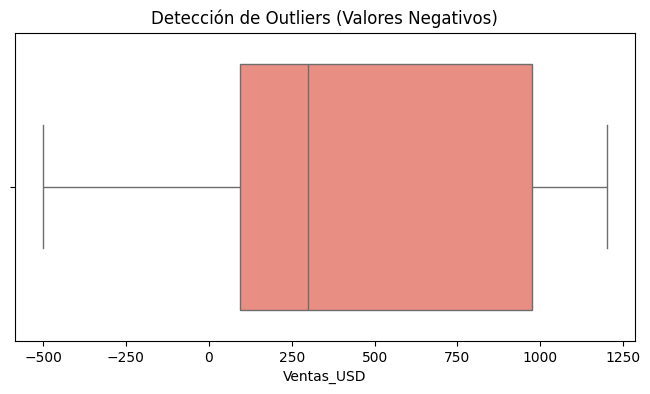

--- Conteo de errores inicial ---
Producto      0
Ventas_USD    1
Fecha         0
dtype: int64


In [1]:
import pandas as pd # Manipulación de tablas
import numpy as np  # Operaciones numéricas (NaN, abs)
import seaborn as sns # Gráficos estadísticos
import matplotlib.pyplot as plt # Control de lienzos

# 1. CREACIÓN DEL DATASET "SUCIO"
# Simulamos una tabla con errores típicos de un sistema de ventas real
data = {
    'Producto': ['Laptop', 'Mouse', 'Monitor', 'Teclado', 'Laptop', 'Mouse', 'Monitor'],
    'Ventas_USD': [1200, -500, 300, np.nan, 1200, 25, 300], # Contiene un negativo y un nulo
    'Fecha': ['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04', '2026-01-01', '05/01/26', '2026-01-03']
}
df_tienda = pd.DataFrame(data)

# 2. VISUALIZACIÓN DE OUTLIERS (DIAGNÓSTICO)
# El Boxplot nos permite ver que el valor -500 está fuera del rango lógico (inferior)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_tienda['Ventas_USD'], color='salmon')
plt.title('Detección de Outliers (Valores Negativos)')
plt.show()

# 3. AUDITORÍA DE NULOS
print("--- Conteo de errores inicial ---")
print(df_tienda.isnull().sum())

## Fase de Limpieza (Data Scrubbing)
Procedemos a aplicar las correcciones necesarias para asegurar la integridad de los datos antes de cualquier análisis estadístico.

In [2]:
# 1. ELIMINACIÓN DE DUPLICADOS
# .drop_duplicates(): Elimina filas idénticas (como la de Laptop y Monitor repetidas)
df_tienda.drop_duplicates(inplace=True)

# 2. CORRECCIÓN DE SIGNOS (NEGATIVOS A POSITIVOS)
# .abs(): Asumimos que el -500 era un error de entrada y lo convertimos en valor absoluto (500)
df_tienda['Ventas_USD'] = df_tienda['Ventas_USD'].abs()

# 3. IMPUTACIÓN DE NULOS (MEDIANA)
# Rellenamos el nulo del 'Teclado' con la mediana de las ventas para no sesgar el total
df_tienda['Ventas_USD'] = df_tienda['Ventas_USD'].fillna(df_tienda['Ventas_USD'].median())

# 4. NORMALIZACIÓN DE FECHAS
# pd.to_datetime: Unifica '2026-01-01' y '05/01/26' al formato estándar AAAA-MM-DD
df_tienda['Fecha'] = pd.to_datetime(df_tienda['Fecha'], errors='coerce', dayfirst=True)

print("✅ Limpieza completada con éxito.")
display(df_tienda)

✅ Limpieza completada con éxito.


,Producto,Ventas_USD,Fecha
0,Laptop,1200.0,2026-01-01
1,Mouse,500.0,2026-02-01
2,Monitor,300.0,2026-03-01
3,Teclado,400.0,2026-04-01
5,Mouse,25.0,NaT


## Visualización de Ventas Reales
Una vez limpios los datos, podemos ver el rendimiento real por categoría de producto sin duplicados ni errores de signo.

C:\Users\txema\AppData\Local\Temp\ipykernel_18360\1433092328.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Producto', y='Ventas_USD', data=df_tienda, palette='viridis', estimator=sum, errorbar=None)


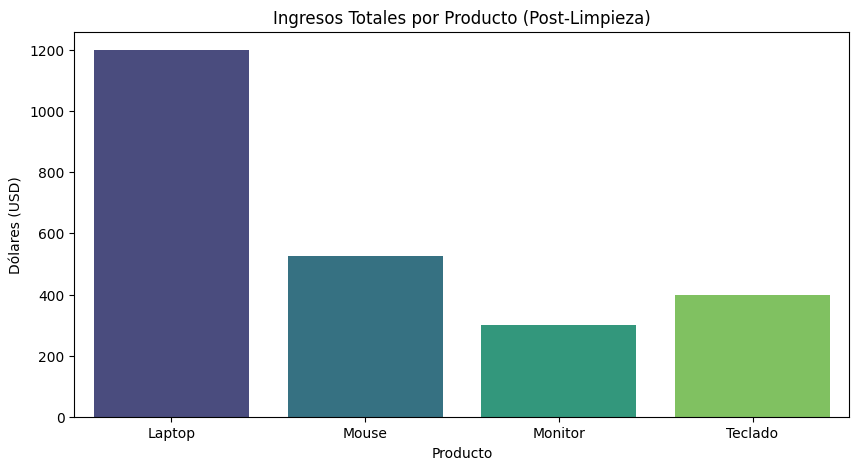

In [3]:
# 1. CONFIGURACIÓN DEL GRÁFICO DE BARRAS
plt.figure(figsize=(10, 5))

# sns.barplot: Sumamos las ventas por cada tipo de producto
# estimator=sum: Asegura que la barra represente el total acumulado
sns.barplot(x='Producto', y='Ventas_USD', data=df_tienda, palette='viridis', estimator=sum, errorbar=None)

plt.title('Ingresos Totales por Producto (Post-Limpieza)')
plt.ylabel('Dólares (USD)')
plt.show()

## Exportación a la Carpeta de Procesados
Guardamos el archivo final en nuestra estructura de datos profesional para que sea accesible desde otros proyectos.

In [4]:
import os

# 1. DEFINICIÓN DE RUTA (RECTIFICADA A 3 NIVELES)
# Subimos 3 niveles para llegar a la raíz desde 'notebooks/datos/caso_tienda/'
folder_dest = '../../../data/processed/'
file_dest = os.path.join(folder_dest, 'tienda_limpia.csv')

# 2. CREACIÓN DE CARPETA (SI NO EXISTE)
os.makedirs(folder_dest, exist_ok=True)

# 3. EXPORTACIÓN A CSV
# index=False evita crear la columna innecesaria de índices de Pandas
df_tienda.to_csv(file_dest, index=False)

# 4. VERIFICACIÓN FINAL DE DISCO
if os.path.exists(file_dest):
    size_kb = os.path.getsize(file_dest) / 1024
    print(f"✅ ARCHIVO EXPORTADO: {file_dest}")
    print(f"📦 Tamaño: {size_kb:.2f} KB")
    print(f"📍 Ruta Absoluta: {os.path.abspath(file_dest)}")
else:
    print("❌ ERROR: No se detecta el archivo en el búnker de datos.")

✅ ARCHIVO EXPORTADO: ../../../data/processed/tienda_limpia.csv
📦 Tamaño: 0.14 KB
📍 Ruta Absoluta: c:\Users\txema\Documents\IA_Especialista\data\processed\tienda_limpia.csv
